# Bandwidth + UCSB ansatz on an 80 ns square pulse

Pipeline:
1. Build an 80 ns square pulse, amplitude 1 (padded on both sides).
2. FFT.
3. Multiply by the 250 MHz -3 dB Gaussian filter `G(f)`.
4. Multiply by the UCSB ansatz (dissertation eq. 8.8 form, matching `apply_alpha_distortion` in cell 28 of `iswap_gaussian_square.ipynb`), applied **iteratively as a product** of single-pole sections:
   $$H(\omega) = \prod_k \left[ 1 + \frac{i\,\alpha_k\,\omega}{i\,\omega + 1/\tau_k} \right]$$
   where `τ_k` is the time constant. The denominator carries the **rate** `1/τ_k` — that's the symbol the dissertation sloppily writes as "τ", but for `iω + τ` to be dimensionally consistent it has to have rate units.
5. IFFT back to time domain.

**Parameter convention.** `τ_k` is a time scale. The supplied list is `1/τ_k` in **GHz**; invert to get `τ_k`. Since `1 GHz = 1/ns` numerically, the inversion lands directly in ns.

**Per-section limits.**
- `ωτ ≪ 1` → factor → 1
- `ωτ ≫ 1` → factor → 1 + α
- 3 dB corner at `f = 1/(2π·τ_k)`
- `α = -1` reduces the section to `1/(1 + iωτ)` — the pure low-pass `apply_exp_distortion` of cell 27 (`distorted.pdf`).

In [186]:
using FFTW
using CairoMakie
using ColorSchemes

## 1. Build the square pulse (80 ns, amplitude 1)

In [187]:
# Time grid
dt_coarse = 2.0e-9          # 2 ns coarse step
M         = 100             # upsampling factor → dt_fine = 0.02 ns (Nyquist = 25 GHz)
dt_fine   = dt_coarse / M

T_total     = 200e-9        # 200 ns total window
pulse_width = 80e-9         # 80 ns pulse
pulse_start = (T_total - pulse_width) / 2     # centered: 60 ns
pulse_end   = pulse_start + pulse_width       # 140 ns

N_coarse = Int(round(T_total / dt_coarse)) + 1
N_fine   = (N_coarse - 1) * M + 1

# Coarse rectangular pulse
u_coarse = zeros(Float64, N_coarse)
i_start  = Int(floor(pulse_start / dt_coarse)) + 1
i_end    = Int(floor(pulse_end   / dt_coarse))
u_coarse[i_start:i_end] .= 1.0

# ZOH upsample to fine grid
u_zoh = vcat(repeat(u_coarse[1:end-1], inner=(M,)), u_coarse[end])
@assert length(u_zoh) == N_fine

t_coarse_ns = (0:N_coarse-1) .* dt_coarse .* 1e9
t_fine_ns   = (0:N_fine-1)   .* dt_fine   .* 1e9

println("N_coarse = $N_coarse, N_fine = $N_fine")
println("dt_fine  = $(dt_fine*1e9) ns,  Nyquist = $(1/(2*dt_fine)/1e9) GHz")
println("Pulse spans $(t_coarse_ns[i_start]) ns → $(t_coarse_ns[i_end]) ns  (width $(pulse_width*1e9) ns)")
println("Padding: $(pulse_start*1e9) ns pre, $((T_total - pulse_end)*1e9) ns post")

N_coarse = 101, N_fine = 10001
dt_fine  = 0.02 ns,  Nyquist = 24.999999999999996 GHz
Pulse spans 58.00000000000001 ns → 136.0 ns  (width 80.0 ns)
Padding: 59.99999999999999 ns pre, 60.00000000000001 ns post


## 2. FFT frequency axis + filter helpers

In [188]:
"""
FFT frequency axis (Hz) for length N and timestep dt (s),
matching the bin ordering of fft(u).
"""
function fftfreq(N::Int, dt::Float64)
    df = 1.0 / (N * dt)
    freqs = [k <= N ÷ 2 ? k : k - N for k in 0:N-1]
    return df .* freqs
end

"""
Gaussian amplitude response with given -3 dB bandwidth B3dB (Hz).
|G(f)| = exp(-f²/(2 σ_f²)),  σ_f = B3dB / sqrt(ln 2).
"""
function gaussian_filter(freqs, B3dB_Hz::Float64)
    σf = B3dB_Hz / sqrt(log(2.0))
    @. exp(-0.5 * (freqs^2) / σf^2)
end

"""
UCSB ansatz transfer function (matches cell 28 of iswap_gaussian_square.ipynb,
i.e. the dissertation eq. 8.8 form), applied iteratively as a product:

    H(ω) = Π_k [ 1 + (i·α_k·ω) / (i·ω + 1/τ_k) ]

τ_k is a TIME constant (seconds). The denominator contains the rate 1/τ_k
(which is the symbol the dissertation sloppily writes as "τ"). ω = 2πf.

Per section:
  ωτ → 0     : factor → 1
  ωτ → ∞     : factor → 1 + α
  α = -1     : factor → 1 / (1 + iωτ)  (a pure 1-pole low-pass, cell 27 form)

Inputs:
  freqs_Hz   : ordinary frequency axis (Hz), FFT-ordered
  αs         : per-pole α_k (dimensionless)
  τrs_s      : per-pole time constants τ_k in seconds
"""
function ucsb_ansatz_product(freqs_Hz,
                             αs::AbstractVector{<:Real},
                             τrs_s::AbstractVector{<:Real})
    @assert length(αs) == length(τrs_s)
    ω = 2π .* freqs_Hz                          # rad/s
    H = ones(ComplexF64, length(freqs_Hz))
    for (α, τr) in zip(αs, τrs_s)
        τ_rate = 1.0 / τr                       # 1/s — the dissertation's "τ" symbol
        @. H *= 1 + (1im * α * ω) / (1im * ω + τ_rate)
    end
    return H
end

freqs = fftfreq(N_fine, dt_fine)            # Hz, FFT-ordered
println("df = $(freqs[2]*1e-6) MHz,  fmax = $(maximum(freqs)*1e-9) GHz")

df = 4.999500049995 MHz,  fmax = 24.997500249975005 GHz


## 3. Build the two filters

- `G(f)`: 250 MHz -3 dB Gaussian (the same one used in bandwidth.ipynb).
- `H(f)`: UCSB ansatz — product of 11 single-pole sections, parameters supplied below.

In [189]:
B3dB_Hz = 250e6
G_f = gaussian_filter(freqs, B3dB_Hz)

# Single-pole test in the cell-28 / dissertation form:
#   H(ω) = 1 + (i·α·ω) / (i·ω + 1/τ_r)
# τ_r is a TIME constant (ns). The helper plugs 1/τ_r as the rate.
inv_τs_GHz = [ 1 / 4 ]      # → τ_r = 4 ns
αs         = [ 0.5  ]       # ±0.5 sweep in cell 28; here we pick +0.5

τrs_ns = 1.0 ./ inv_τs_GHz                          # 1 GHz = 1/ns → ns directly
τrs_s  = τrs_ns .* 1e-9                             # ns → seconds for the helper

H_f     = ucsb_ansatz_product(freqs, αs, τrs_s)
F_total = G_f .* H_f

println("# pole sections: $(length(αs))")
println("τ_r (ns):  ", round.(τrs_ns, digits=2))
println("αs:        ", round.(αs,     digits=5))

# pole sections: 1
τ_r (ns):  [4.0]
αs:        [0.5]


## 4. Apply: FFT → multiply → IFFT

In [190]:
# Stage 1: rect → 250 MHz Gaussian filter  ⇒  "gaussian square"
U     = fft(u_zoh)
u_g   = real.(ifft(G_f .* U))               # the gaussian-square pulse

# Stage 2: gaussian square → UCSB ansatz H(f)  ⇒  final distorted pulse
U_g    = fft(u_g)
u_both = real.(ifft(H_f .* U_g))            # gaussian-filtered AND UCSB-distorted

println("max |u_g|    = $(maximum(abs, u_g))    # after stage 1 (Gaussian only)")
println("max |u_both| = $(maximum(abs, u_both)) # after stage 2 (Gaussian + UCSB)")

max |u_g|    = 1.0000000000000009    # after stage 1 (Gaussian only)
max |u_both| = 1.35575300805336 # after stage 2 (Gaussian + UCSB)


## 5. Time-domain plot

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/andrewkamen/.julia/packages/Makie/FUAHr/src/scenes.jl:238


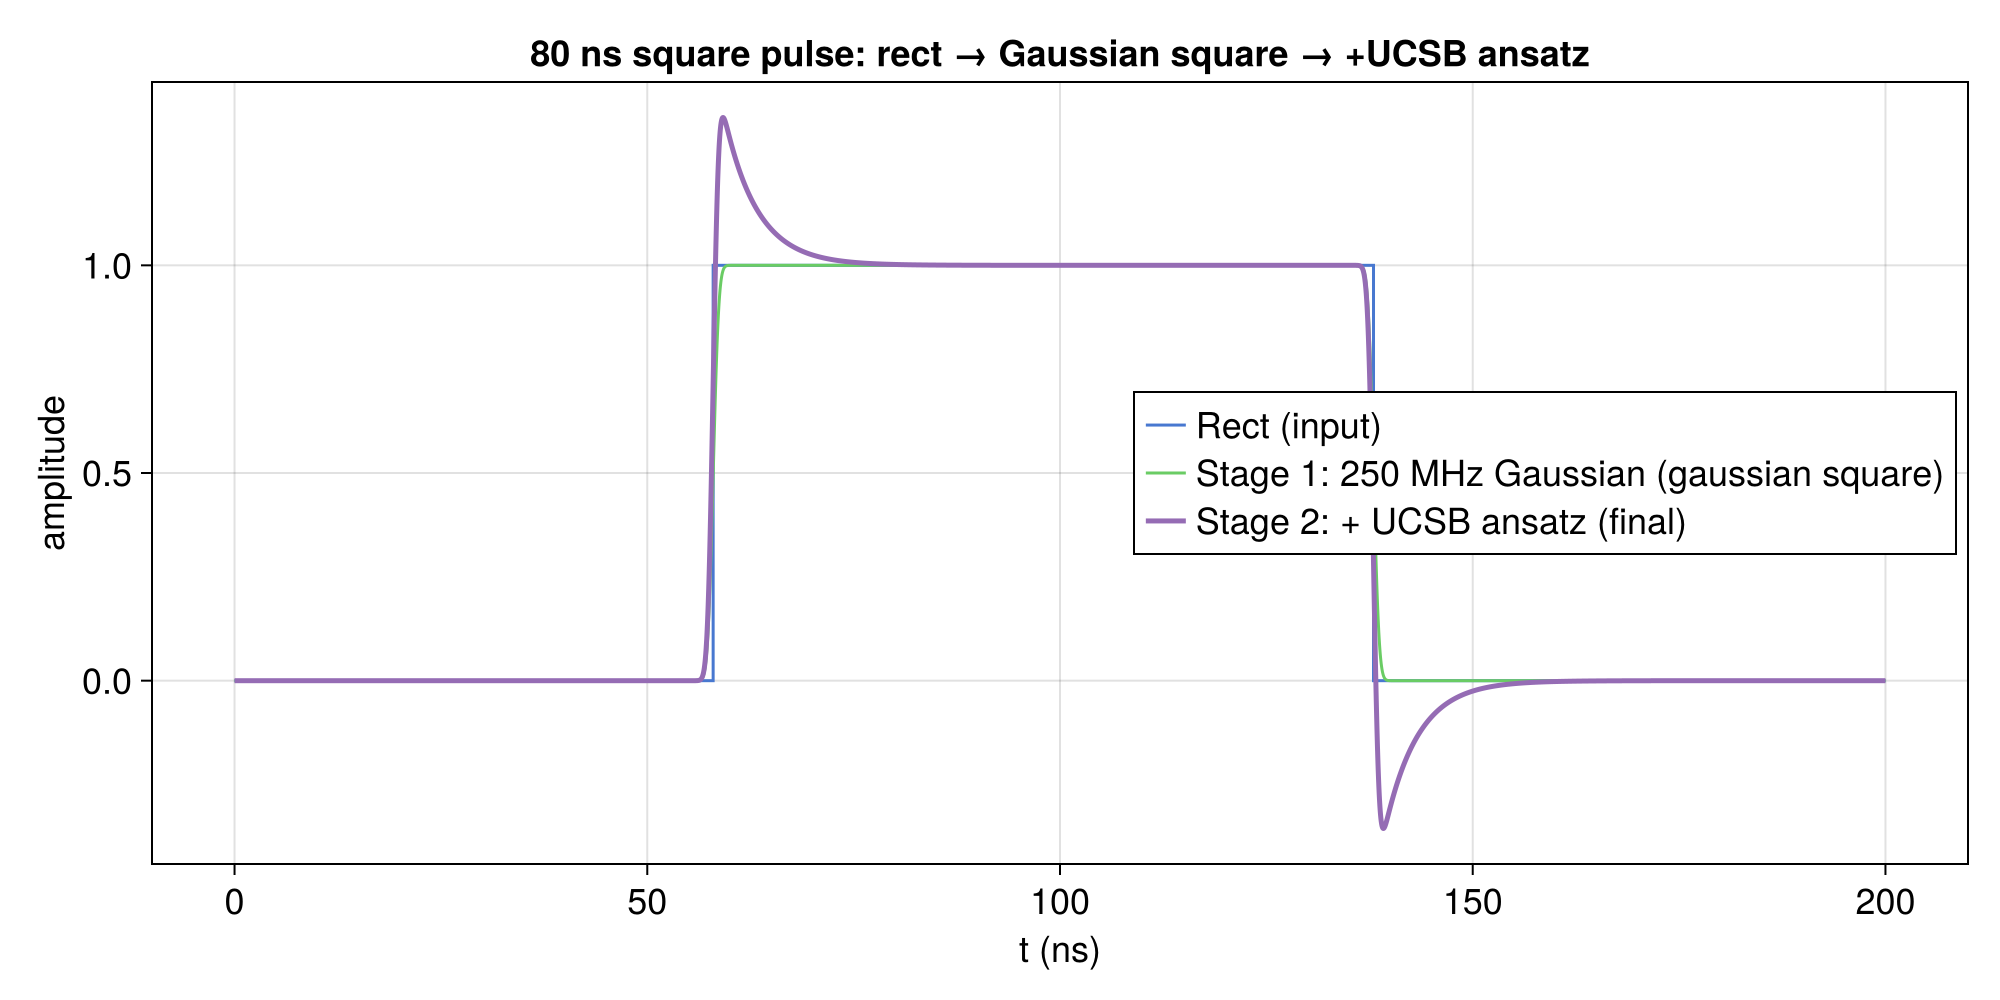

In [191]:
CairoMakie.activate!()
cols = ColorSchemes.seaborn_muted6.colors
c_rect, c_gauss, c_both = cols[1], cols[2], cols[4]

fig = Figure(resolution = (1000, 500), fontsize = 18)
ax = Axis(fig[1, 1],
    xlabel = "t (ns)",
    ylabel = "amplitude",
    title  = "80 ns square pulse: rect → Gaussian square → +UCSB ansatz",
)

stairs!(ax, t_fine_ns, u_zoh;  color = c_rect,  label = "Rect (input)")
lines!( ax, t_fine_ns, u_g;    color = c_gauss, label = "Stage 1: 250 MHz Gaussian (gaussian square)")
lines!( ax, t_fine_ns, u_both; color = c_both,  linewidth = 2.5,
        label = "Stage 2: + UCSB ansatz (final)")

axislegend(ax, position = :rc)
fig

## 6. Frequency-domain plot

Plot only the positive-frequency half (sorted), in MHz, on a log y-axis.

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/andrewkamen/.julia/packages/Makie/FUAHr/src/scenes.jl:238


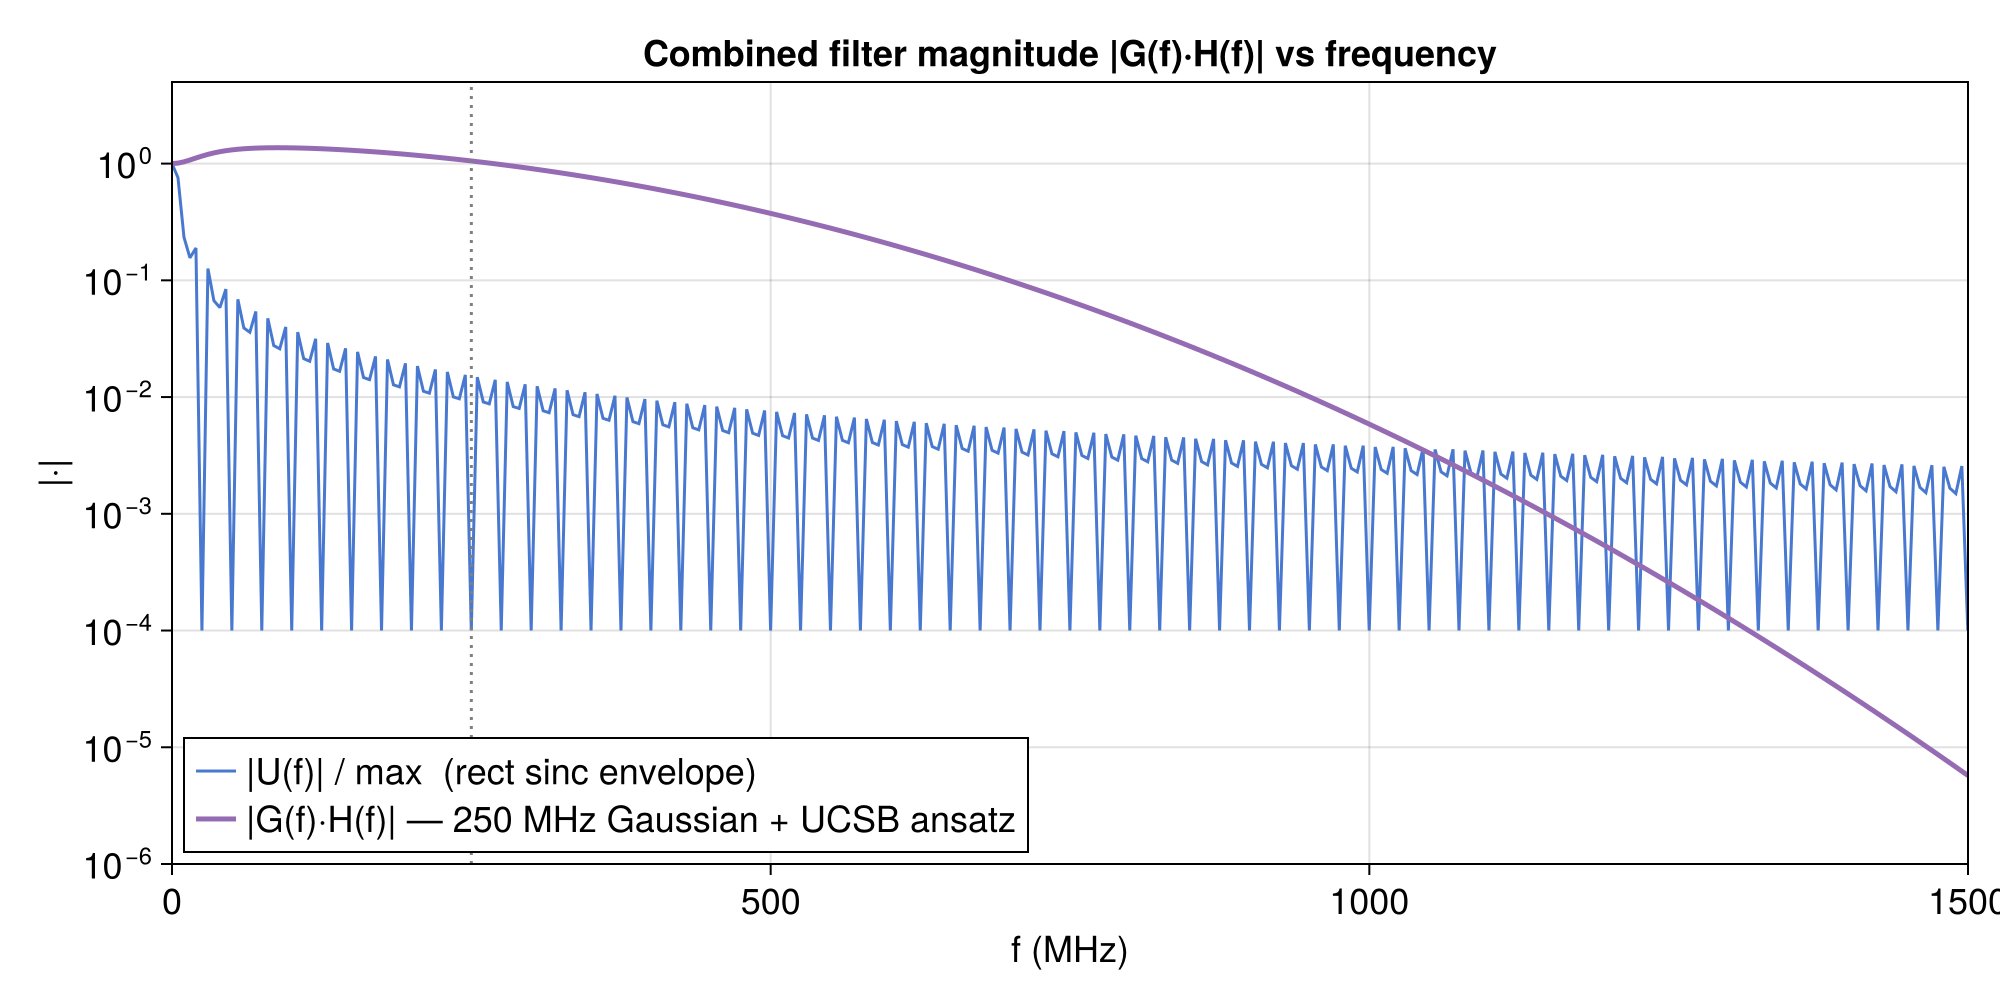

In [192]:
# Positive-frequency mask, sorted ascending
pos          = freqs .>= 0
f_pos_MHz    = freqs[pos] .* 1e-6
perm         = sortperm(f_pos_MHz)
f_pos_MHz    = f_pos_MHz[perm]
F_pos        = abs.((G_f .* H_f)[pos])[perm]    # combined |G·H| — the actual applied filter
U_pos        = abs.(U[pos])[perm]
U_pos_norm   = U_pos ./ maximum(U_pos)          # normalize sinc envelope for readability

fig2 = Figure(resolution = (1000, 500), fontsize = 18)
ax2 = Axis(fig2[1, 1],
    xlabel = "f (MHz)",
    ylabel = "|·|",
    yscale = log10,
    title  = "Combined filter magnitude |G(f)·H(f)| vs frequency",
)

lines!(ax2, f_pos_MHz, U_pos_norm; color = c_rect, label = "|U(f)| / max  (rect sinc envelope)")
lines!(ax2, f_pos_MHz, F_pos;      color = c_both, linewidth = 2.5,
       label = "|G(f)·H(f)| — 250 MHz Gaussian + UCSB ansatz")

vlines!(ax2, [250.0]; color = :gray, linestyle = :dot)

xlims!(ax2, 0, 1500)
ylims!(ax2, 1e-6, 5.0)
axislegend(ax2, position = :lb)
fig2

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/andrewkamen/.julia/packages/Makie/FUAHr/src/scenes.jl:238


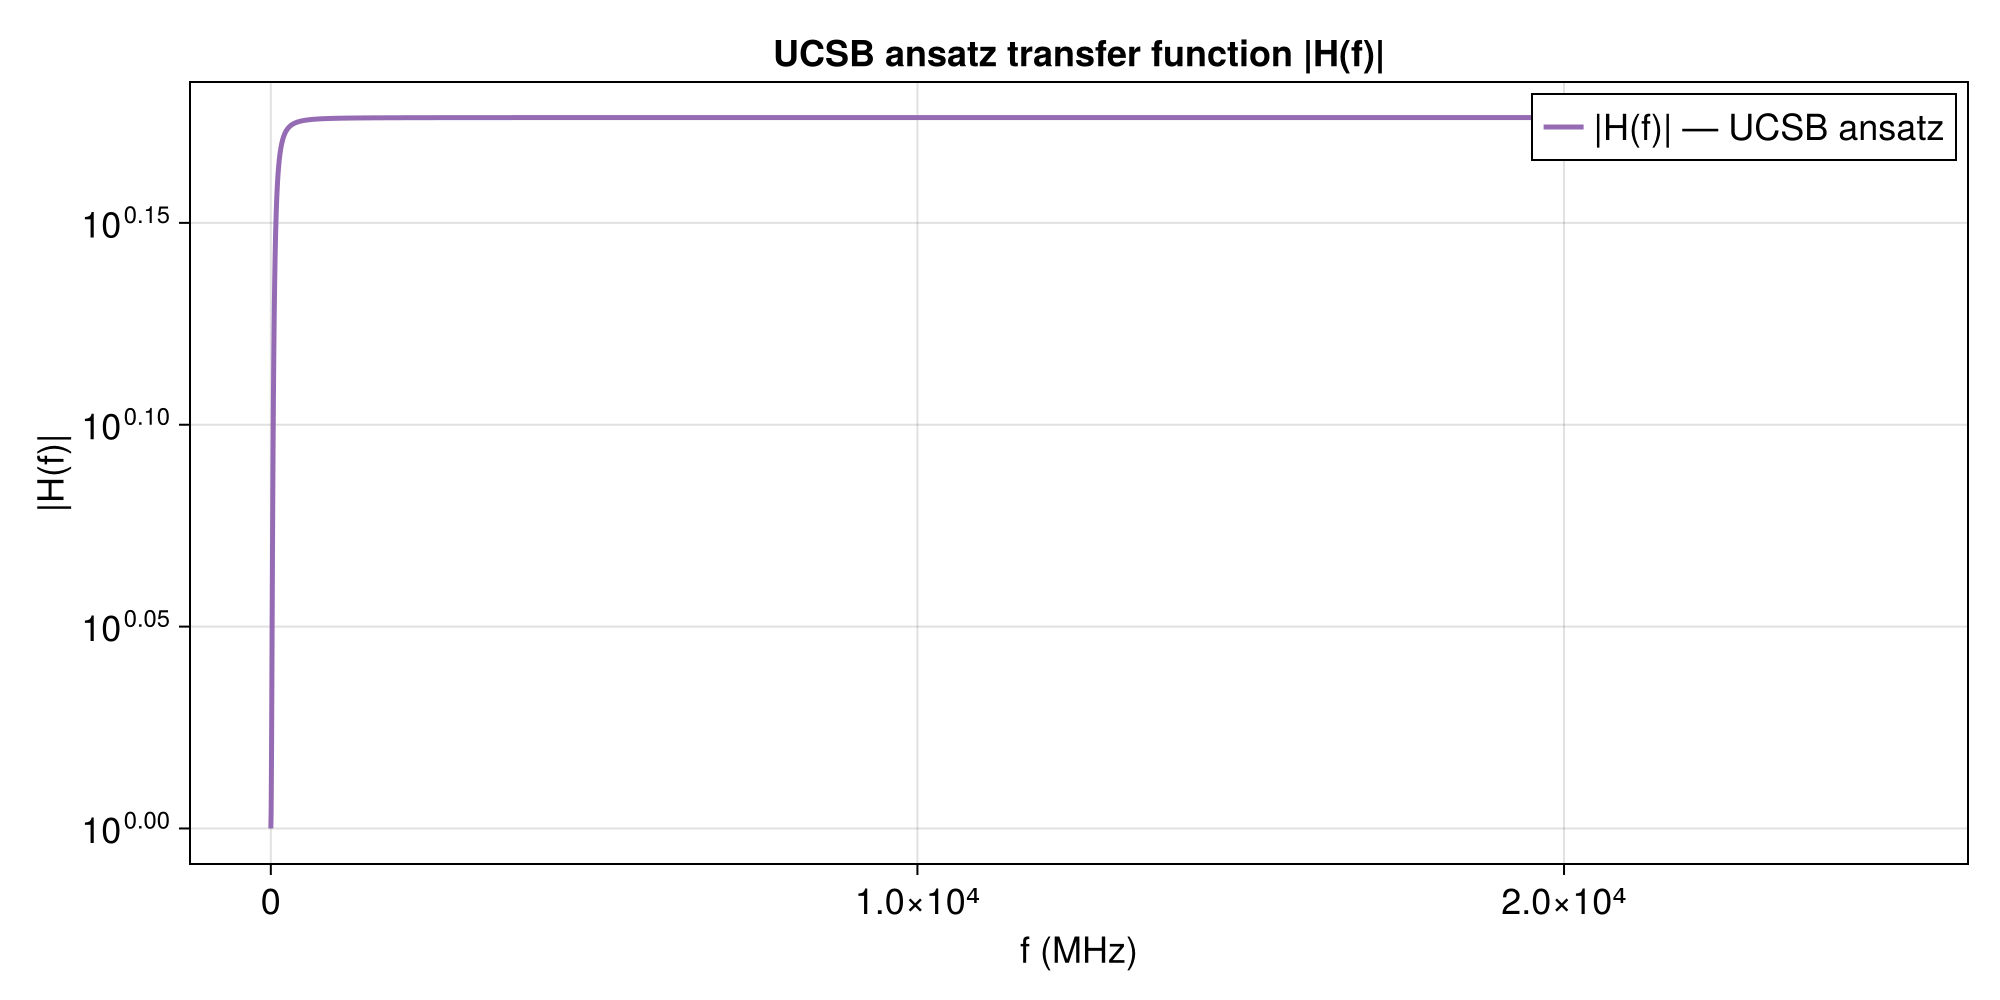

In [193]:
# Plot only |H(f)| — UCSB ansatz transfer function alone
H_pos = abs.(H_f[pos])[perm]

fig3 = Figure(resolution = (1000, 500), fontsize = 18)
ax3 = Axis(fig3[1, 1],
    xlabel = "f (MHz)",
    ylabel = "|H(f)|",
    yscale = log10,
    title  = "UCSB ansatz transfer function |H(f)|",
)

lines!(ax3, f_pos_MHz, H_pos; color = c_both, linewidth = 2.5,
       label = "|H(f)| — UCSB ansatz")

axislegend(ax3, position = :rt)
fig3

## 7. Single-pole sanity check: α = 0.5, τ_r = 4 ns

Test the pipeline with one overshoot pole instead of the 11-section product. Same 250 MHz Gaussian first, then `H(ω) = 1 + 0.5·iωτ_r/(1 + iωτ_r)` with τ_r = 4 ns.

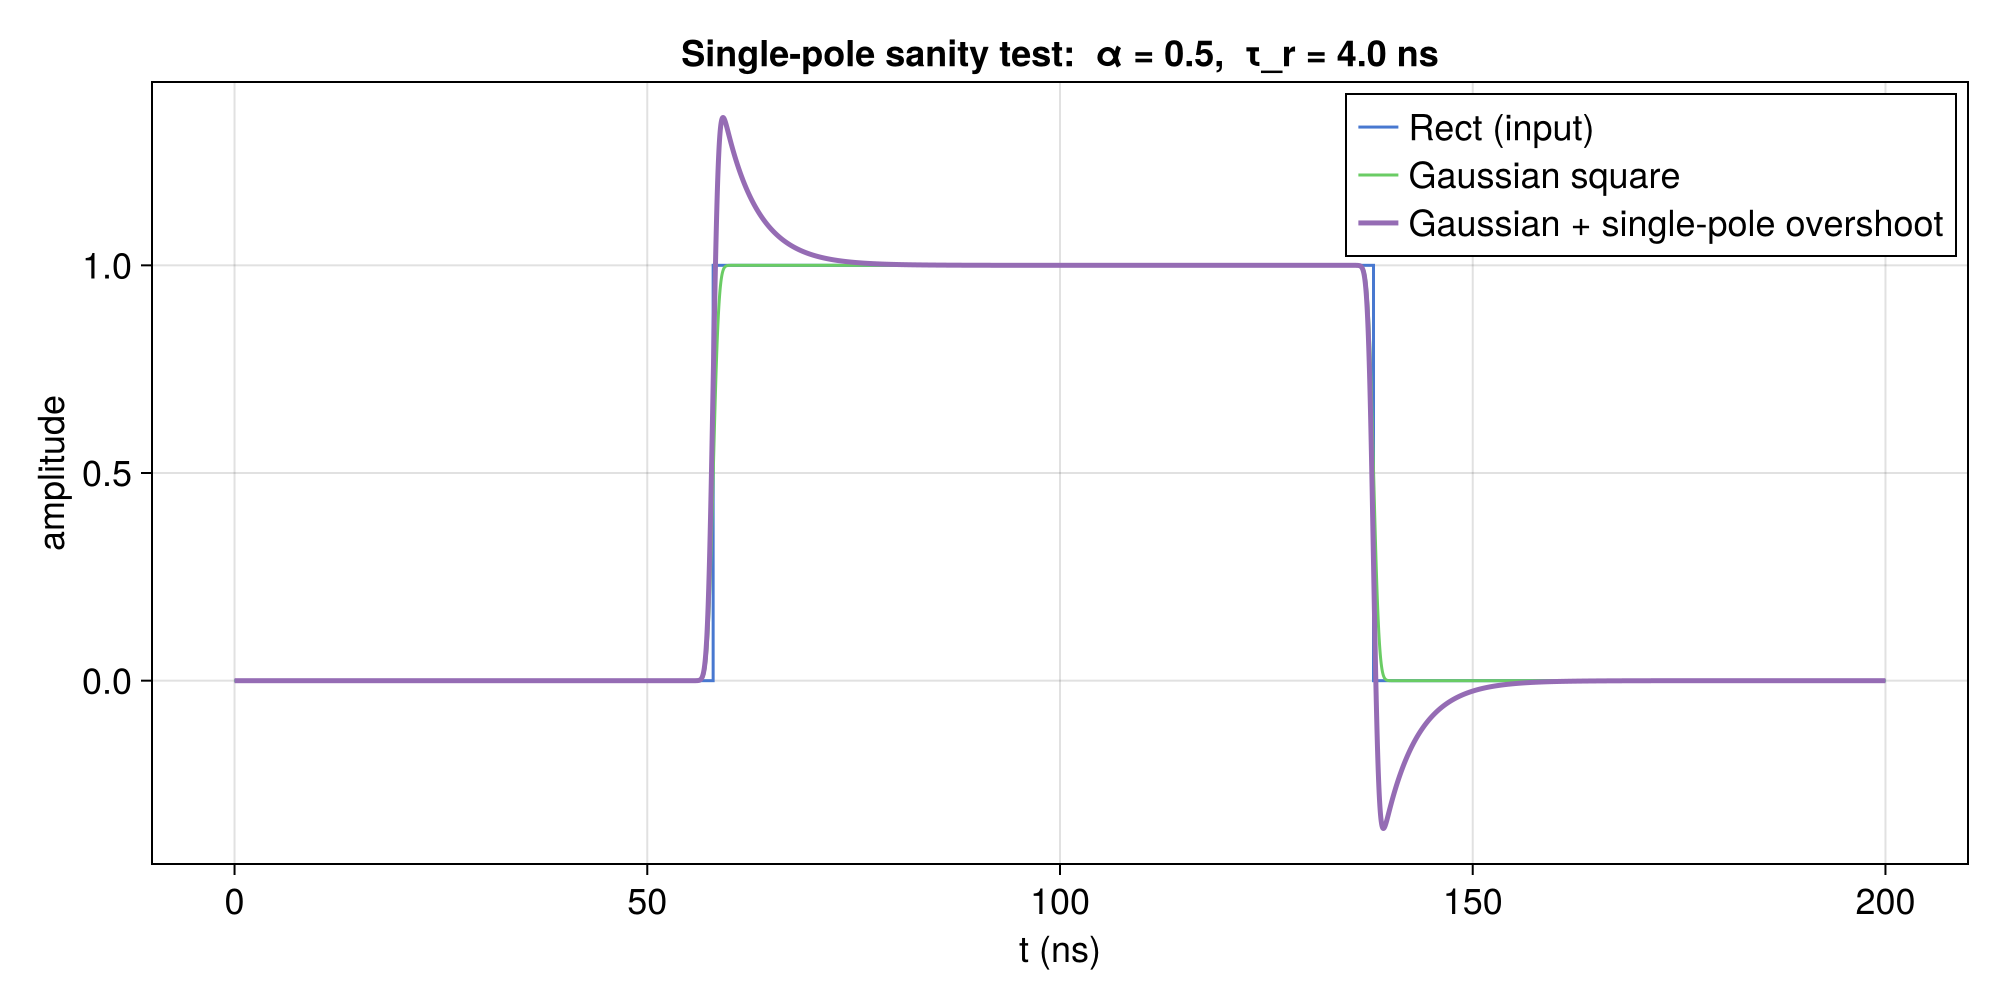

α = 0.5,  τ_r = 4.0 ns
max |u_g|         = 1.0000000000000009
max |u_test_both| = 1.35575300805336


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/andrewkamen/.julia/packages/Makie/FUAHr/src/scenes.jl:238
┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/andrewkamen/.julia/packages/Makie/FUAHr/src/scenes.jl:238


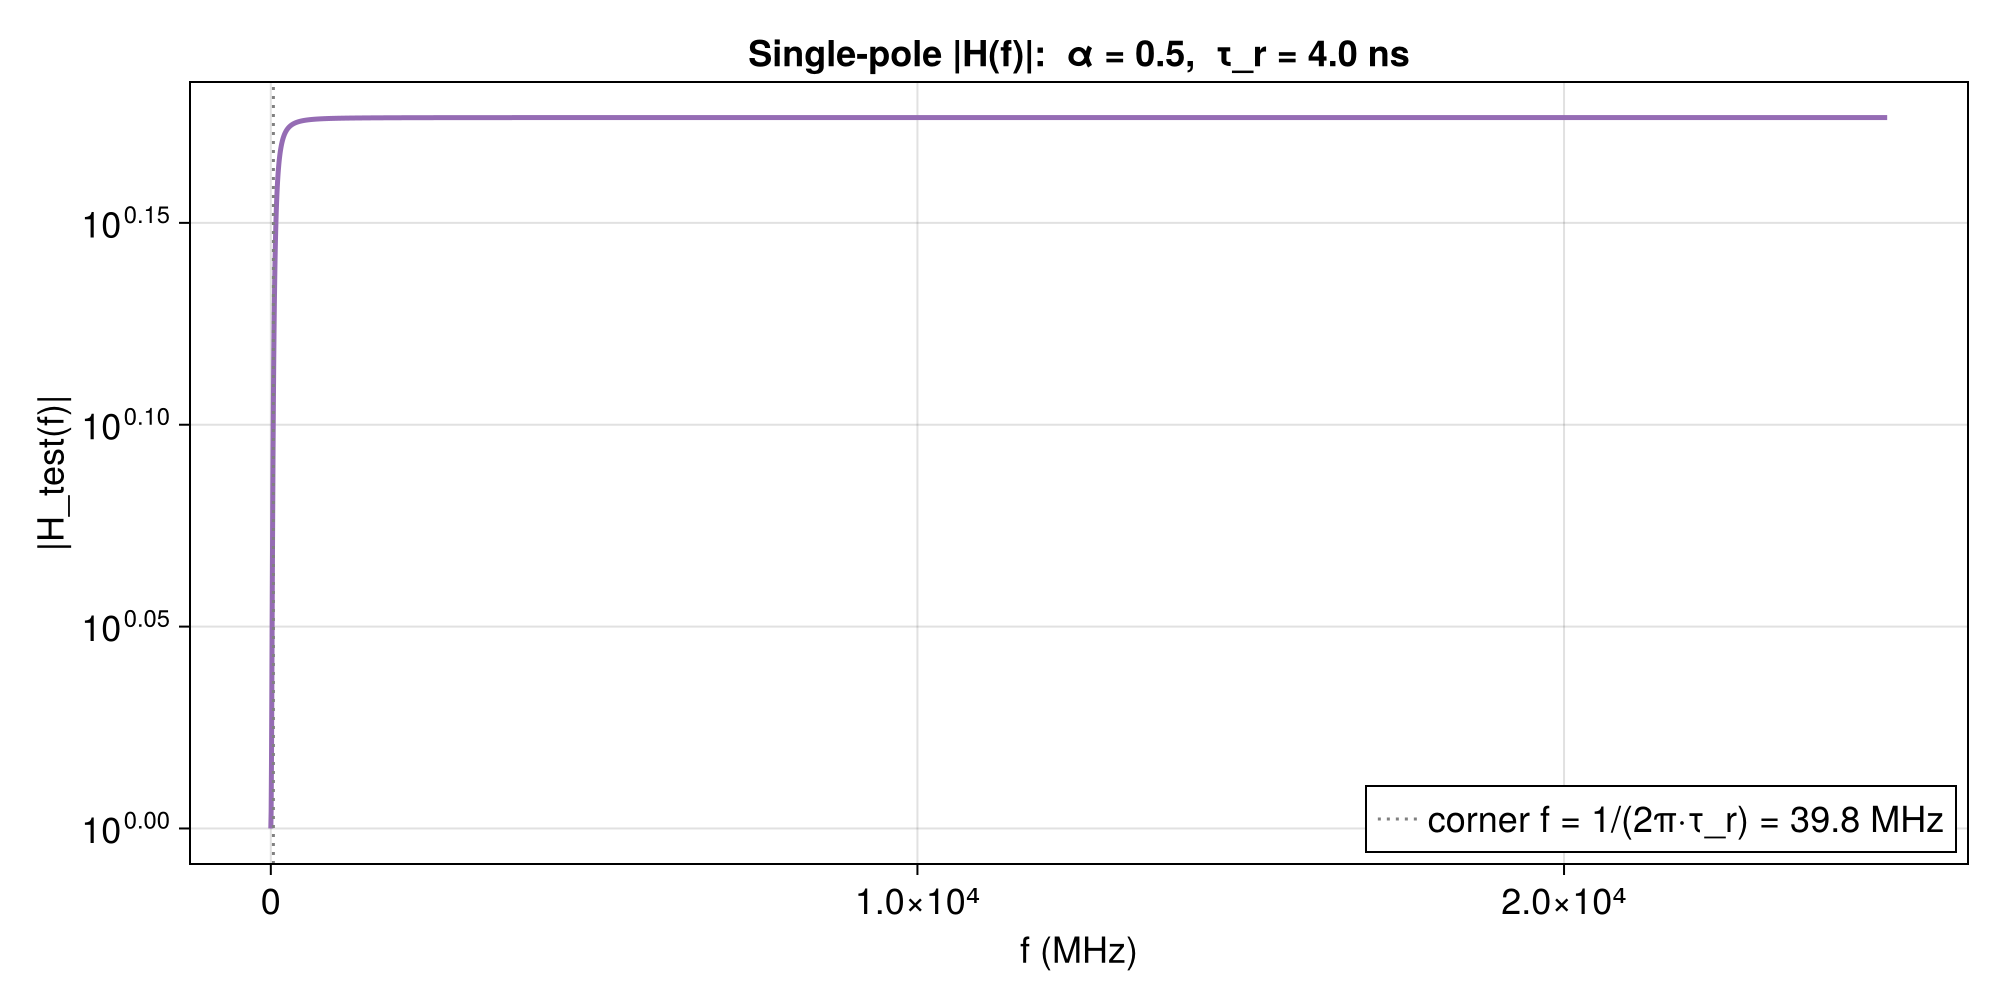

In [194]:
# Single-pole test: α = 0.5, τ_r = 4 ns
α_test  = 0.5
τr_ns   = 4.0
τr_s    = τr_ns * 1e-9

# Build H_test(f) using the same helper as the 11-section product
H_test = ucsb_ansatz_product(freqs, [α_test], [τr_s])

# Apply on top of the gaussian-square (u_g from cell-apply)
U_g_test     = fft(u_g)
u_test_both  = real.(ifft(H_test .* U_g_test))   # Gaussian + single-pole overshoot

println("α = $α_test,  τ_r = $τr_ns ns")
println("max |u_g|         = $(maximum(abs, u_g))")
println("max |u_test_both| = $(maximum(abs, u_test_both))")

# --- Time-domain plot ---
fig_t = Figure(resolution = (1000, 500), fontsize = 18)
ax_t  = Axis(fig_t[1, 1],
    xlabel = "t (ns)",
    ylabel = "amplitude",
    title  = "Single-pole sanity test:  α = $α_test,  τ_r = $τr_ns ns",
)

stairs!(ax_t, t_fine_ns, u_zoh;        color = c_rect,  label = "Rect (input)")
lines!( ax_t, t_fine_ns, u_g;          color = c_gauss, label = "Gaussian square")
lines!( ax_t, t_fine_ns, u_test_both;  color = c_both,  linewidth = 2.5,
        label = "Gaussian + single-pole overshoot")

axislegend(ax_t, position = :rt)
display(fig_t)

# --- |H_test(f)| plot ---
H_test_pos = abs.(H_test[pos])[perm]

fig_f = Figure(resolution = (1000, 500), fontsize = 18)
ax_f  = Axis(fig_f[1, 1],
    xlabel = "f (MHz)",
    ylabel = "|H_test(f)|",
    yscale = log10,
    title  = "Single-pole |H(f)|:  α = $α_test,  τ_r = $τr_ns ns",
)
lines!(ax_f, f_pos_MHz, H_test_pos; color = c_both, linewidth = 2.5)

# corner of α·iωτ/(1+iωτ) is at ωτ = 1, i.e. f_corner = 1/(2π·τ_r)
f_corner_MHz = 1.0 / (2π * τr_s) * 1e-6
vlines!(ax_f, [f_corner_MHz]; color = :gray, linestyle = :dot,
        label = "corner f = 1/(2π·τ_r) = $(round(f_corner_MHz, digits=1)) MHz")
axislegend(ax_f, position = :rb)
fig_f

## 8. Full Xuntao fit (11 poles) — time-domain evaluation

Same pipeline (Gaussian filter → UCSB ansatz product) but with the **experimental Xuntao parameters** (`α_k`, `1/τ_k`) loaded in. Each pole uses the same dissertation form `1 + iα_k ω/(iω + 1/τ_k)`. Shown alongside the rect, the gaussian-square, and the 4 ns single-pole reference.

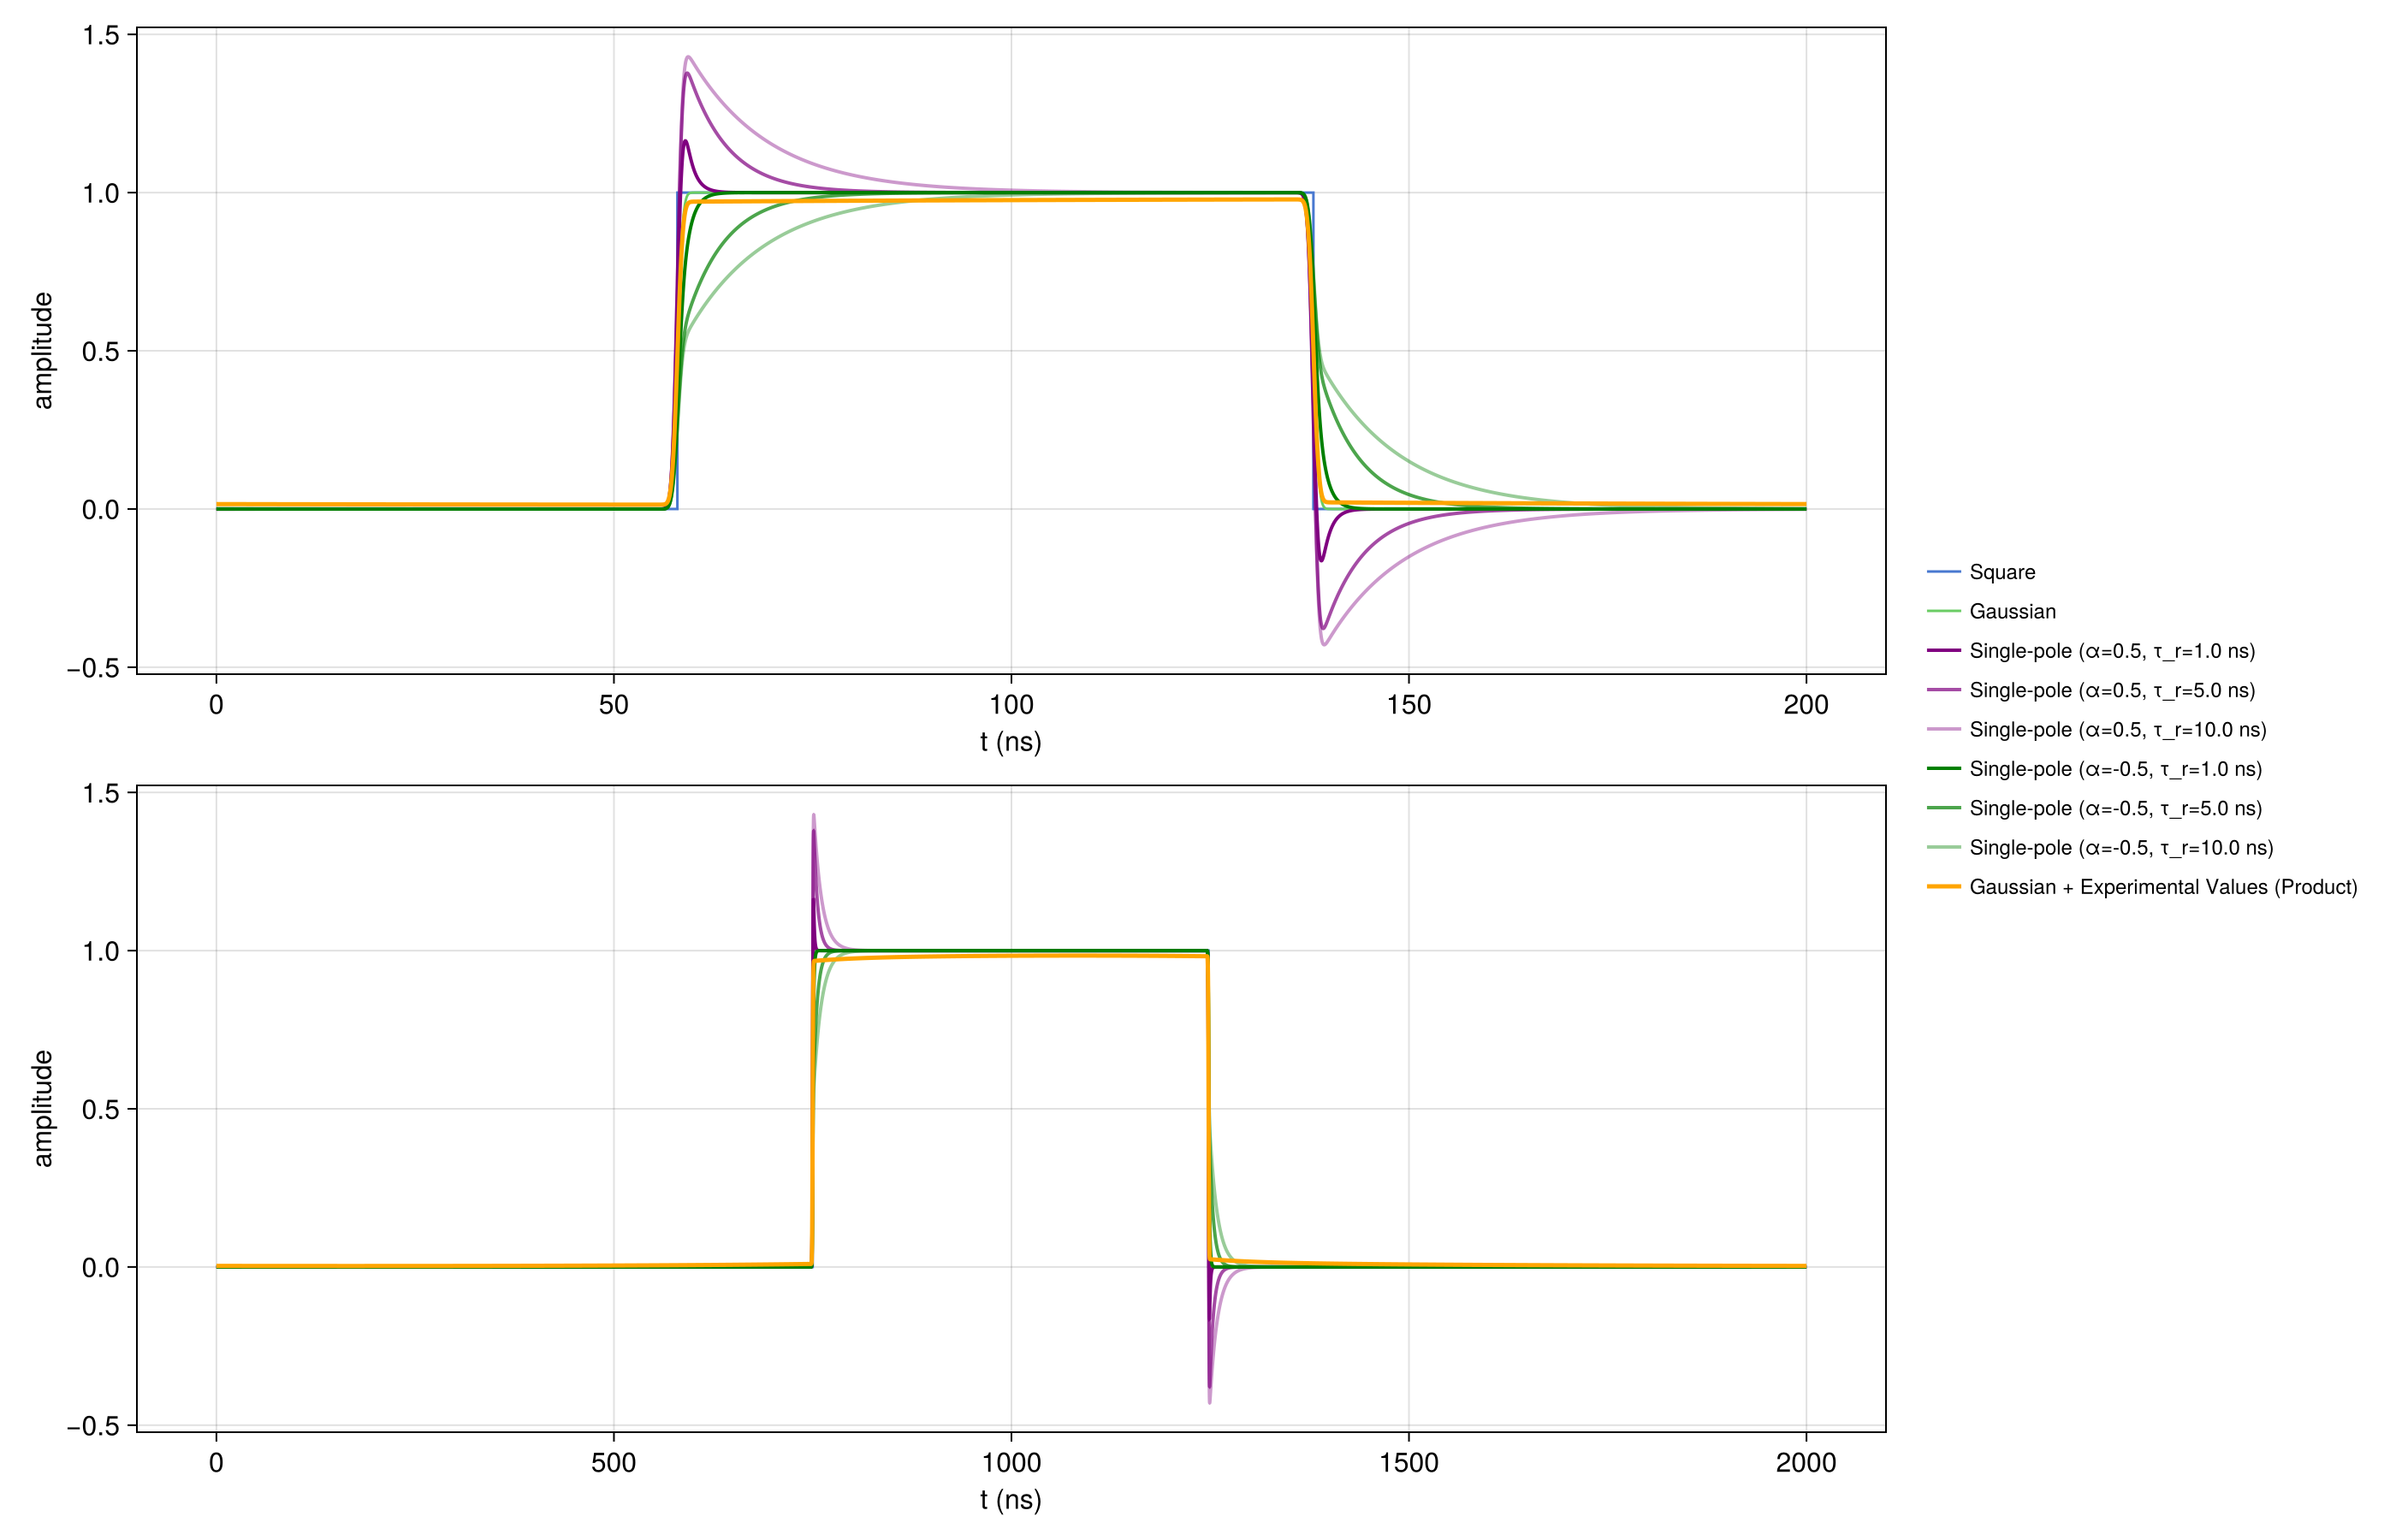

# Xuntao pole sections: 11
rates τ_k (MHz): [1.379, -1.991, 2.107, 2.187, 1.932, 1.783, -4.975, 2.713, 4.168, -4.377, 16.769]
τ_r (ns):        [725.32, -502.15, 474.71, 457.3, 517.56, 560.79, -201.02, 368.58, 239.9, -228.46, 59.63]
Π(1+α_k):        0.95731


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/andrewkamen/.julia/packages/Makie/FUAHr/src/scenes.jl:238


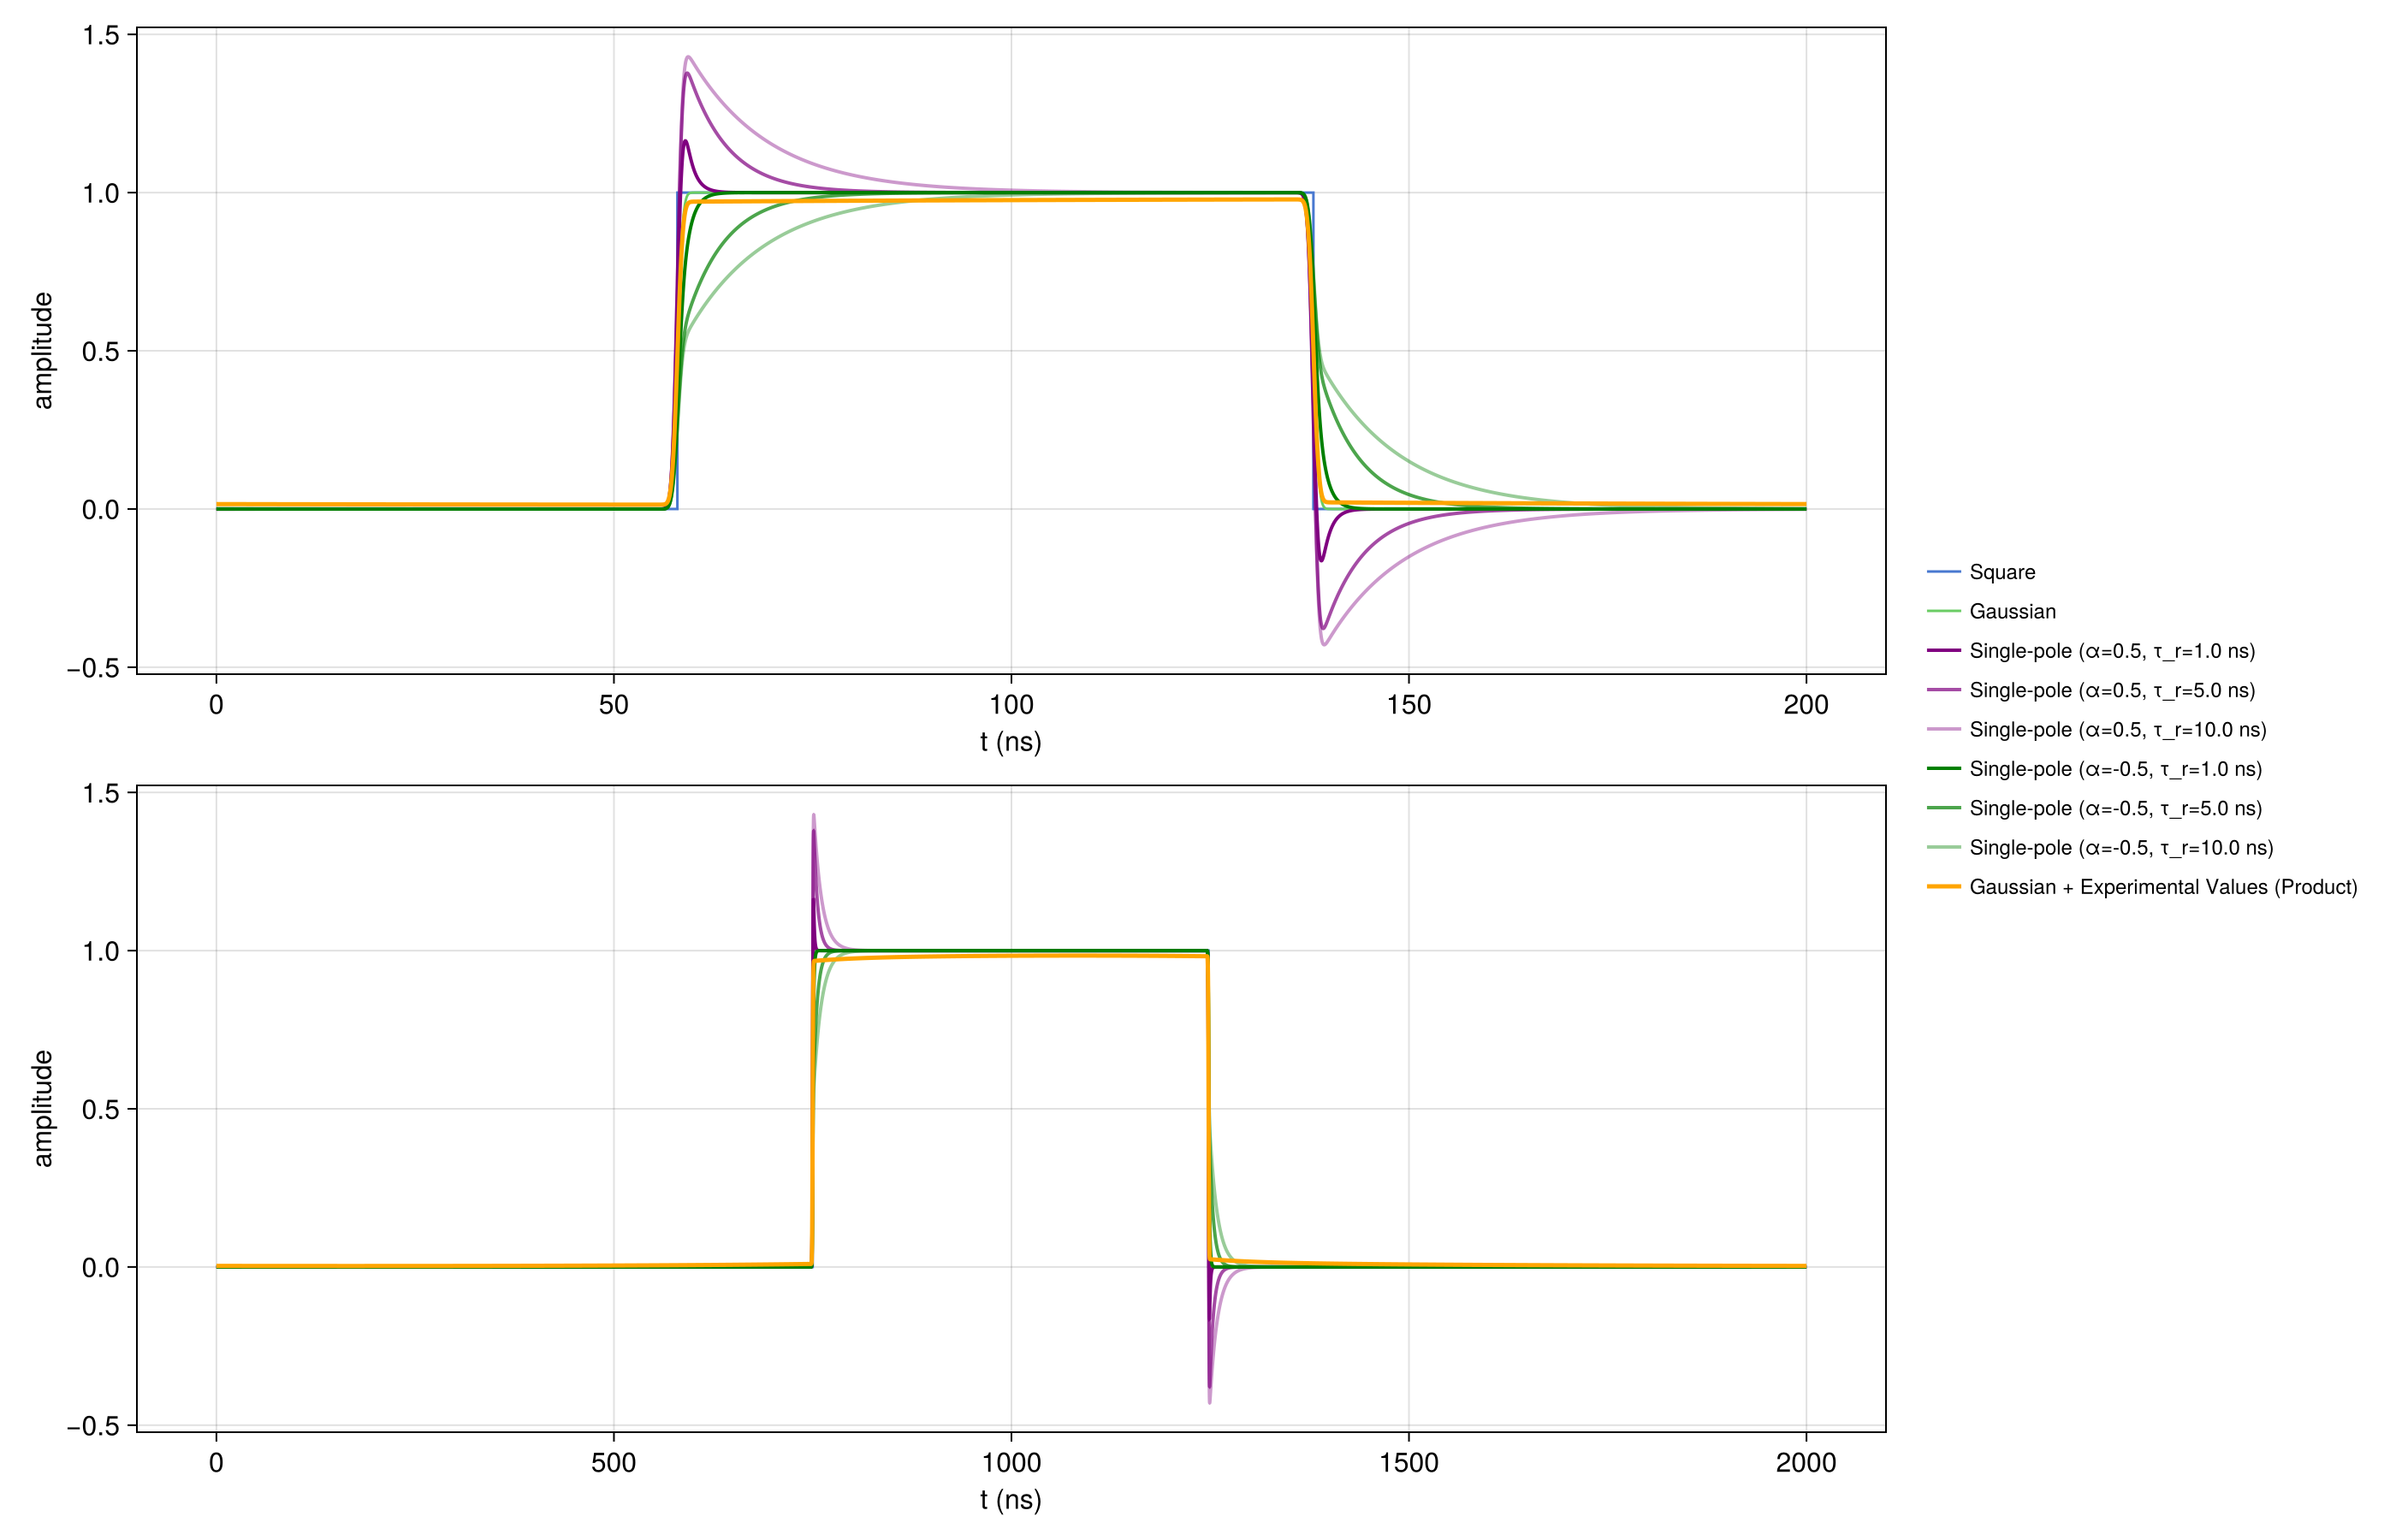

In [198]:
# --- Xuntao experimental fit parameters (11 single-pole sections) ---
# Xuntao supplied the *rates* τ_k (in GHz) that go in the denominator of
# the dissertation form H = 1 + iαω/(iω + τ).
τrates_GHz_xt = [
     0.0013787070345065407,
    -0.0019914488609231442,
     0.0021065393022981676,
     0.0021867703359130007,
     0.0019321412282041152,
     0.0017831967374612823,
    -0.004974549282819448,
     0.0027131107101415813,
     0.0041684177440696035,
    -0.004377157100167196,
     0.016769056998526106,
]

αs_xt = [
    -0.0021354269532686963,
    -0.00465614577928213,
    -0.004521252927173405,
    -0.0036956387019408702,
    -0.002702611132983166,
    -0.0019411827453214665,
    -0.004707693562520176,
    -0.002660791767856395,
    -0.0031399519790246007,
    -0.0022364765662448213,
    -0.011110845564803778,
]

τrates_Hz_xt = τrates_GHz_xt .* 1e9            # rate, 1/s
τrs_ns_xt    = 1.0 ./ τrates_GHz_xt            # τ_r, ns
τrs_s_xt     = 1.0 ./ τrates_Hz_xt             # τ_r, s

println("# Xuntao pole sections: $(length(αs_xt))")
println("rates τ_k (MHz): ", round.(τrates_GHz_xt .* 1e3, digits=3))
println("τ_r (ns):        ", round.(τrs_ns_xt,             digits=2))
println("Π(1+α_k):        ", round(prod(1 .+ αs_xt),       digits=5))

# --- Single-pole sweep (iswap distorted.pdf style) ---
sweep_τr_ns = [1.0, 5.0, 10.0]                 # ns
sweep_αs    = [0.5, -0.5]                      # ±0.5
α_to_color  = Dict( 0.5 => :purple,            # α > 0 → purple
                   -0.5 => :green)             # α < 0 → green

# -----------------------------------------------------------------------------
# Self-contained pipeline: rect → Gaussian → Xuntao + single-pole (α,τ_r) sweep
# -----------------------------------------------------------------------------
function run_pipeline(T_total_s::Float64, pulse_width_s::Float64;
                      dt_coarse_s::Float64 = 2.0e-9,
                      M_up::Int            = 100,
                      B3dB_Hz::Float64     = 250e6)
    dt_fine_s     = dt_coarse_s / M_up
    pulse_start_s = (T_total_s - pulse_width_s) / 2
    pulse_end_s   = pulse_start_s + pulse_width_s

    N_c = Int(round(T_total_s / dt_coarse_s)) + 1
    N_f = (N_c - 1) * M_up + 1

    u_c = zeros(Float64, N_c)
    i0  = Int(floor(pulse_start_s / dt_coarse_s)) + 1
    i1  = Int(floor(pulse_end_s   / dt_coarse_s))
    u_c[i0:i1] .= 1.0
    u_z = vcat(repeat(u_c[1:end-1], inner=(M_up,)), u_c[end])

    t_ns_local  = (0:N_f-1) .* dt_fine_s .* 1e9
    freqs_local = fftfreq(N_f, dt_fine_s)
    G_local     = gaussian_filter(freqs_local, B3dB_Hz)
    H_xt_local  = ucsb_ansatz_product(freqs_local, αs_xt, τrs_s_xt)

    U_z   = fft(u_z)
    u_g_l = real.(ifft(G_local .* U_z))
    U_g_l = fft(u_g_l)
    u_xt  = real.(ifft(H_xt_local .* U_g_l))

    # Sweep over (α, τ_r) single-pole sections
    u_sp = Dict{Tuple{Float64,Float64},Vector{Float64}}()
    for α_sp in sweep_αs, τr_ns_sp in sweep_τr_ns
        H_sp = ucsb_ansatz_product(freqs_local, [α_sp], [τr_ns_sp * 1e-9])
        u_sp[(α_sp, τr_ns_sp)] = real.(ifft(H_sp .* U_g_l))
    end

    return (t_ns = t_ns_local, u_zoh = u_z, u_g = u_g_l, u_xt = u_xt, u_sp = u_sp)
end

# --- Plot helper: no title, labels & color gradient as requested -------------
function plot_pipeline!(ax, R)
    stairs!(ax, R.t_ns, R.u_zoh; color = c_rect,  label = "Square")
    lines!( ax, R.t_ns, R.u_g;   color = c_gauss, label = "Gaussian")

    for α_sp in sweep_αs
        basecolor = α_to_color[α_sp]
        for (idx, τr_ns_sp) in enumerate(sweep_τr_ns)
            shade = 1.0 - 0.3 * (idx - 1)      # iswap-style transparency
            lines!(ax, R.t_ns, R.u_sp[(α_sp, τr_ns_sp)];
                   color = (basecolor, shade), linewidth = 2.0,
                   label = "Single-pole (α=$α_sp, τ_r=$(τr_ns_sp) ns)")
        end
    end

    lines!(ax, R.t_ns, R.u_xt; color = :orange, linewidth = 2.5,
           label = "Gaussian + Experimental Values (Product)")
end

# --- Short window: 200 ns total, 80 ns pulse ---
R_short = run_pipeline(200e-9, 80e-9)

# --- Long window: 2000 ns total, 500 ns pulse ---
R_long  = run_pipeline(2000e-9, 500e-9)

fig = Figure(resolution = (1400, 900), fontsize = 16)

ax_short = Axis(fig[1, 1], xlabel = "t (ns)", ylabel = "amplitude")
plot_pipeline!(ax_short, R_short)

ax_long  = Axis(fig[2, 1], xlabel = "t (ns)", ylabel = "amplitude")
plot_pipeline!(ax_long, R_long)

# Single shared legend on the right, drawn from the top axis
Legend(fig[1:2, 2], ax_short, framevisible = false, labelsize = 12)

display(fig)
fig